<img src=https://www.udc.es/export/sites/udc/silazarillo/_galeria_imgs/03_Simbolo_logo_cor.png_2063069294.png width="300" align="left">
<br />

# Modelos Avanzados de Aprendizaje automático II
#### <font color=green>*Grado en Inteligencia Artificial*</font>

# Tema 1: Agrupamiento (clustering)

#### Ejercicio sobre el uso de algoritmos de agrupamiento ($k$-medias y DBSCAN) sobre los siguientes conjuntos de datos:
#### 1. Conjunto de datos artificial de 2 dimensiones con 3 grupos (clústeres).
#### 2. Conjunto de datos artificial de 32 dimensiones con 16 grupos (clústeres).

#### Se cargan las librerías necesarias:

In [3]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans,  DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, v_measure_score, rand_score, adjusted_rand_score
from scipy.spatial.distance import pdist
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import fcluster, dendrogram, linkage
import warnings

### Caso 1: Conjunto de datos artificial de 2 dimensiones con 3 grupos (clústeres).

#### Se generan 200 datos artificiales en 2 dimensiones empleando la función [make_blobs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) de la librería scikit-learn. Para ello se generarán datos con distribuciones Gaussians isotrópicas con 3 centros diferentes y desviación típica de 0.5:

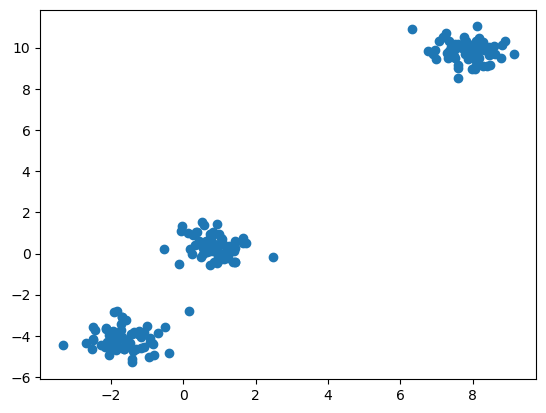

In [13]:
X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.5)
plt.scatter(X[:,0], X[:,1]);

#### Se realiza el agrupamiento (clustering) mediante el uso del método [$k$-medias](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), con inicialización aleatoria de centroides. Para determinar el mejor valor de $k$ se probará con valores entre 1 y 15 y se guardará en una lista la medida de inercia de cada uno de los modelos:

In [21]:
warnings.filterwarnings("ignore")
k_list = [x for x in range(1,16)]
distortions = []
for k in k_list:
    model = KMeans(n_clusters=k, init= "random" )
    model.fit(X)
    distortions.append(model.inertia_)

#### Se muestra gráficamente el valor de la inercia con los valores de $k$ entre 1 y 15 para poder determinar el mejor valor de $k$:

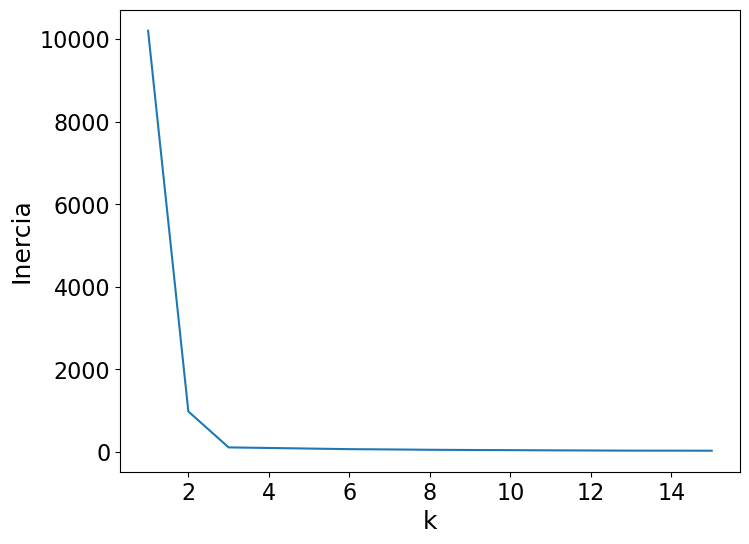

In [20]:
plt.figure(figsize = (8,6))
plt.plot(k_list, distortions)
plt.xlabel("k", fontsize = 18)
plt.ylabel("Inercia", fontsize = 18)
plt.setp(plt.gca().get_xticklabels(), fontsize=16)
plt.setp(plt.gca().get_yticklabels(), fontsize=16)
plt.show()

#### Se muestra gráficamente el resultado del agrupamiento para el mejor valor de $k$ observando la gráfica anterior. Para ello, se realizará de nuevo el entrenamiento del modelo para ese valor concreto de $k$. En la gráfica se mostrará también el centroide de cada grupo mediante el uso de punto en color rojo. Para crear la gráfica se recomienda el uso del método [scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) y el método [legend_elements](https://matplotlib.org/stable/api/collections_api.html#matplotlib.collections.PathCollection.legend_elements) para definir los elementos de la leyenda:

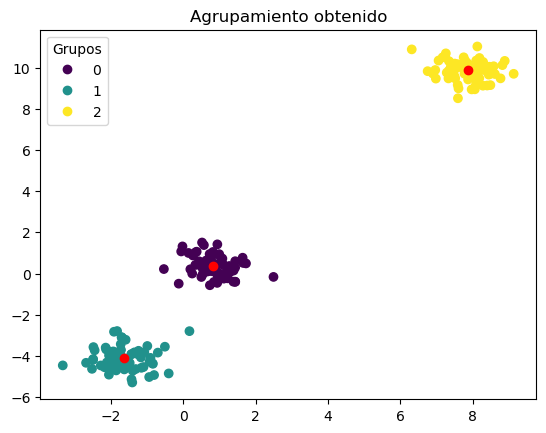

In [22]:
kmeans = KMeans(n_clusters=3, init="random")
kmeans.fit(X)
centers = kmeans.cluster_centers_

plt.title("Agrupamiento obtenido")
scatter = plt.scatter(X[:,0], X[:,1], c = kmeans.labels_, cmap="viridis")
plt.legend(*scatter.legend_elements(), title = "Grupos")
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker = "o", color = "red")

#### Cálculo del coeficiente de silueta ([Silhouette Coefficient](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)). Para determinar el mejor valor de $k$ se probará con valores entre 2 y 15 y se guardará en una lista el valor de coeficiente para cada uno de los modelos:

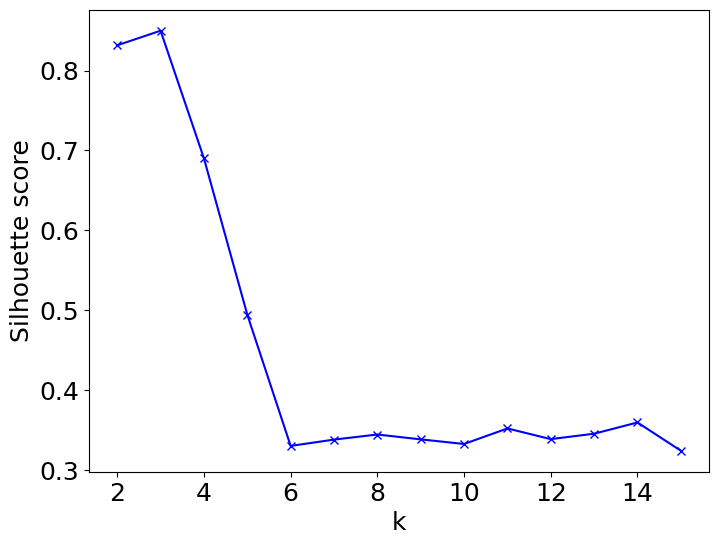

In [23]:
score = []
K = [k for k in range(2,16)]
for k in K:
    kmeansModel = KMeans(n_clusters=k, init="random")
    kmeansModel.fit(X)
    label = kmeansModel.predict(X)
    score.append(silhouette_score(X, label))

plt.figure(figsize=(8,6))
plt.plot(K, score, "bx-")
plt.xlabel("k", fontsize=18)
plt.ylabel("Silhouette score", fontsize =18)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show()

#### Cálculo de la medida V ([V measure](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.v_measure_score.html)). Para determinar el mejor valor de $k$ se probará con valores entre 2 y 15 y se guardará en una lista el valor de la medida para cada uno de los modelos:

In [24]:
score = []
K = [k for k in range(2,16)]
for k in K:
    kmeansModel = KMeans(n_clusters=k, init="random")
    kmeansModel.fit(X)
    label = kmeansModel.predict(X)
    score.append(v_measure_score(X, label))

plt.figure(figsize=(8,6))
plt.plot(K, score, "bx-")
plt.xlabel("k", fontsize=18)
plt.ylabel("Silhouette score", fontsize =18)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show()

ValueError: labels_true must be 1D: shape is (200, 2)

#### Cálculo de las medidas índice Rand ([Rand index](https://scikit-learn.org/stable/modules/clustering.html#rand-index)) e índice Rand ajustado. De nuevo se probarán valores de $k$ entre 2 y 15 y se guardará en una lista el valor de la medida para cada uno de los modelos. 

In [ ]:
score = []
K = [k for k in range(2,16)]
for k in K:
    kmeansModel = KMeans(n_clusters=k, init="random")
    kmeansModel.fit(X)
    label = kmeansModel.predict(X)
    score.append(rand_score(X, label))

plt.figure(figsize=(8,6))
plt.plot(K, score, "bx-")
plt.xlabel("k", fontsize=18)
plt.ylabel("Silhouette score", fontsize =18)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show()

score = []
K = [k for k in range(2,16)]
for k in K:
    kmeansModel = KMeans(n_clusters=k, init="random")
    kmeansModel.fit(X)
    label = kmeansModel.predict(X)
    score.append(silhouette_score(X, label))

plt.figure(figsize=(8,6))
plt.plot(K, score, "bx-")
plt.xlabel("k", fontsize=18)
plt.ylabel("Silhouette score", fontsize =18)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show()

ValueError: labels_true must be 1D: shape is (200, 2)

### Repetir todo el proceso para una inicialización de centroides con $k-means++$

## DBSCAN

#### Se realiza el agrupamiento (clustering) mediante el uso del método [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html). Para determinar el mejor valor de $epsilon$ se calculará la $k$-distancia de cada punto, siendo $k$ = minPts, y se mostrarán gráficamente las $k$-distancias ordenadas de menor a mayor. Para poder determinar la $k$-distancia se recomienda el uso de la función [NearestNeighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html) y para ordenarlas la función [sort](https://numpy.org/doc/stable/reference/generated/numpy.sort.html):

Text(0, 0.5, 'Distancia al k-vecino más cercano')

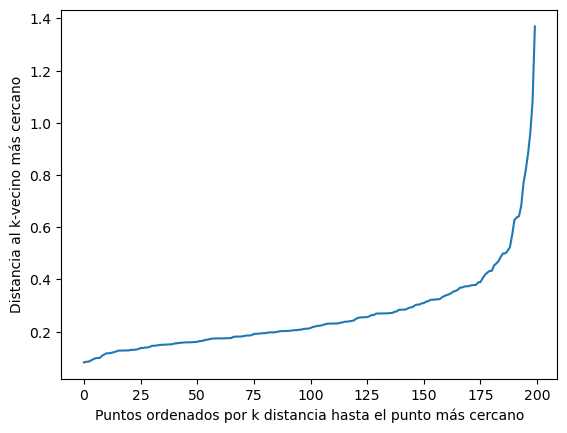

In [26]:
n, dim = X.shape
MinPts = 2*dim

neighbors = NearestNeighbors(n_neighbors=MinPts)
neighbors.fit(X)
distances, indices = neighbors.kneighbors(X)
distances = np.sort(distances[:, MinPts-1])

plt.plot(distances)
plt.xlabel("Puntos ordenados por k distancia hasta el punto más cercano")
plt.ylabel("Distancia al k-vecino más cercano")

#### Se muestra gráficamente el resultado de agrupamiento con DBSCAN para el mejor valor estimado de minPts y $epsilon$. Se indicará también el número de grupos (clústeres) creados y el número de datos clasificados como ruido:

grupos detectados:  3
datos clasificados como ruido:  6


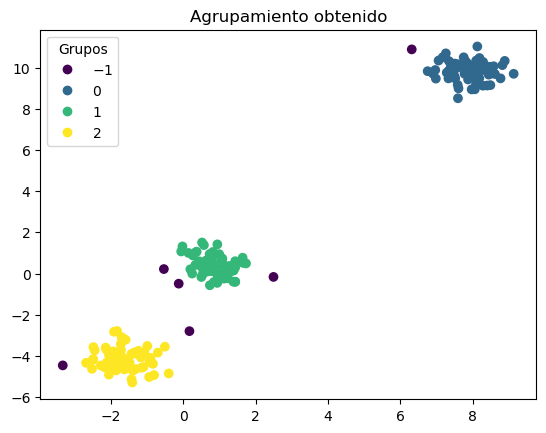

In [27]:
clustering = DBSCAN(eps = 0.6, min_samples= MinPts).fit(X)
n_c = np.max(clustering.labels_)+1
print("grupos detectados: ",n_c)
print("datos clasificados como ruido: ", sum(clustering.labels_ == -1))

plt.title("Agrupamiento obtenido")
scatter = plt.scatter(X[:, 0], X[:,1], c = clustering.labels_, cmap="viridis")
plt.legend(*scatter.legend_elements(), title="Grupos")

#### Se realiza el agrupamiento (clustering) con el método jerárquico mediante el uso de la función [linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html). Para ello, es necesario calcular previamente la matriz de distancias de los datos usando, por ejemplo, la función [pdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html):

In [ ]:
dist = pdist(X)
linkage_matrix = linkage(dist, "complete")

#### Se muestra el dendrograma asociado al método jerárquico con la función [dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html):

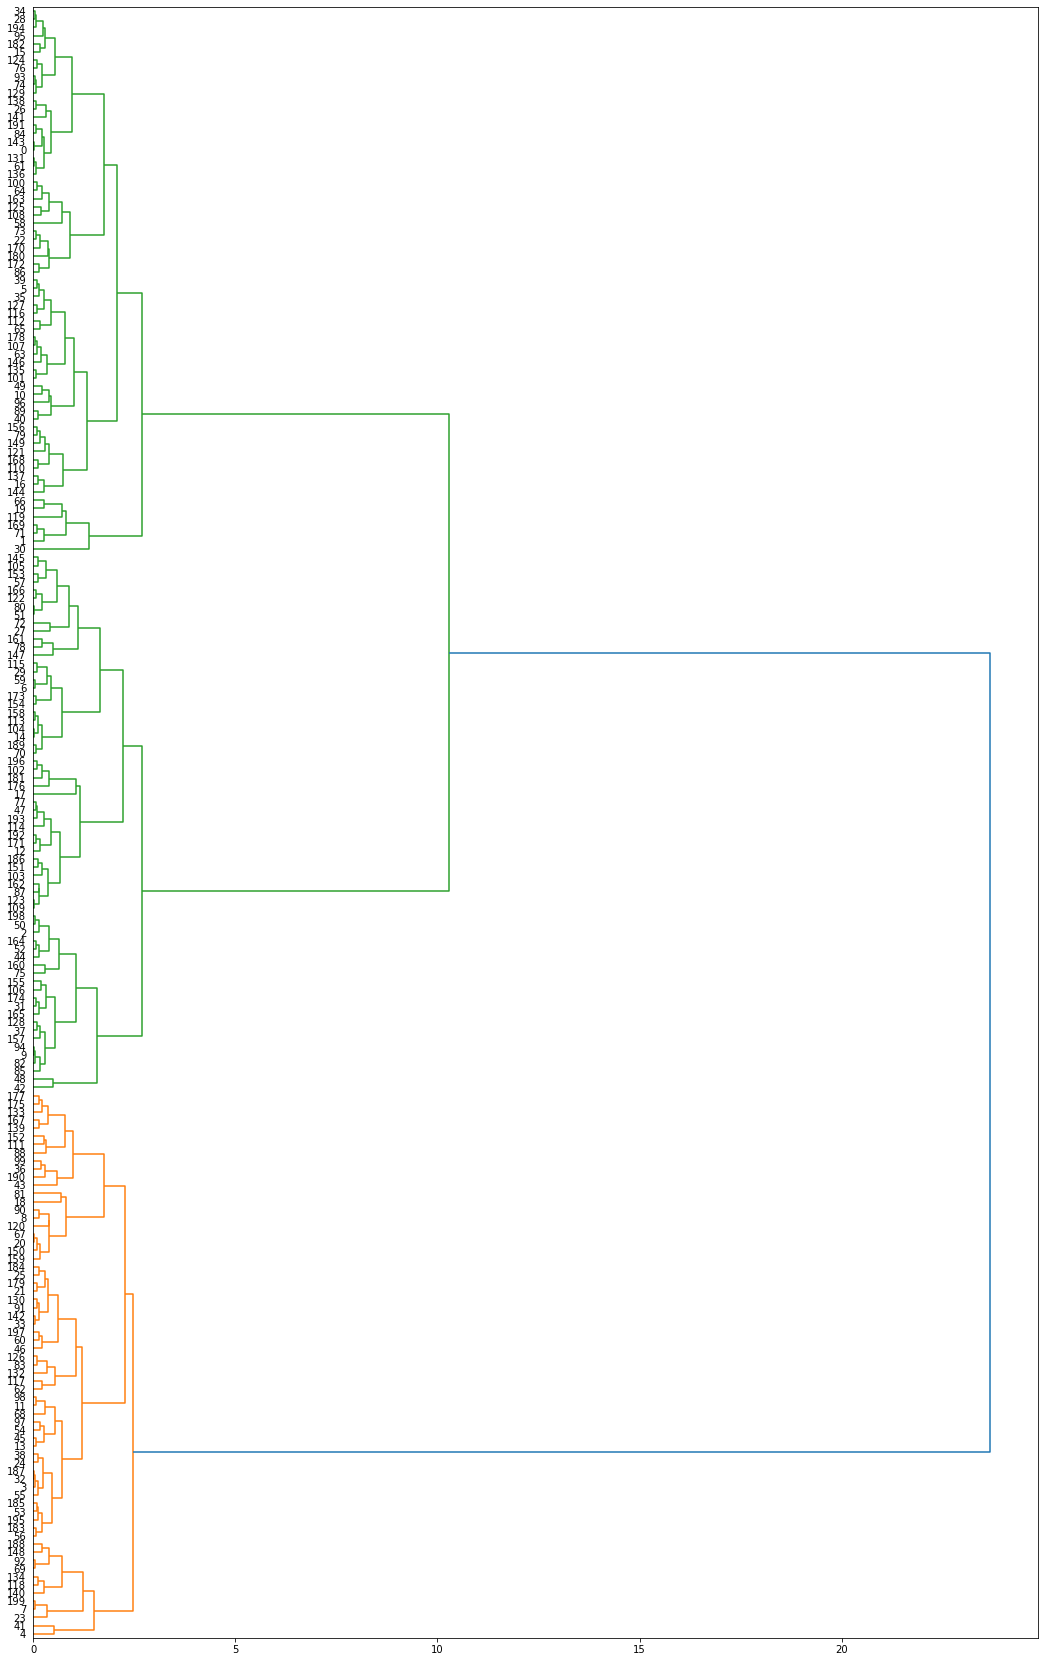

In [ ]:
plt.figure(X)
dendrogram

#### Se muestra el resultado del agrupamiento jerárquico con la función [fcluster](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.fcluster.html). Emplear para ello el argumento criterion='maxclust' para seleccionar el número de grupos:

Número de grupos:  3


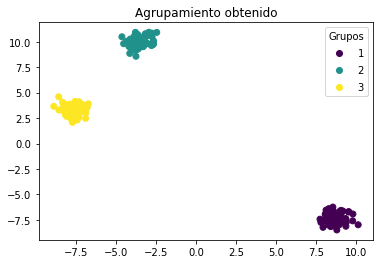

## Caso 2: Conjunto de datos artificial de 32 dimensiones con 16 grupos (clústeres).

#### Se carga de fichero (dim032.txt) con el conjunto de datos procedente de la página web [Clustering basic benchmark](http://cs.joensuu.fi/sipu/datasets/). Se recomienda el uso de la función [loadtxt](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html) para la lectura de los datos:

In [17]:
X = np.loadtxt("dim032.txt")


#### Se realiza el agrupamiento (clustering) mediante el uso del método [$k$-medias](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). Para determinar el mejor valor de $k$ se probará con valores entre 2 y 30 y se guardarán en listas la medida de inercia y el valor del coeficiente de silueta ([Silhouette Coefficient](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)) de cada uno de los modelos:

In [32]:
warnings.filterwarnings("ignore")
score = []
k_list = [x for x in range(2,30)]
distortions = []
for k in k_list:
    model = KMeans(n_clusters=k, init= "random" )
    model.fit(X)
    distortions.append(model.inertia_)
    label = model.predict(X)
    score.append(silhouette_score(X, label))

#### Se muestra en una misma gráfica el valor de la inercia y del coeficiente de silueta, con los valores de $k$ entre 2 y 30, para poder determinar el mejor valor de $k$:

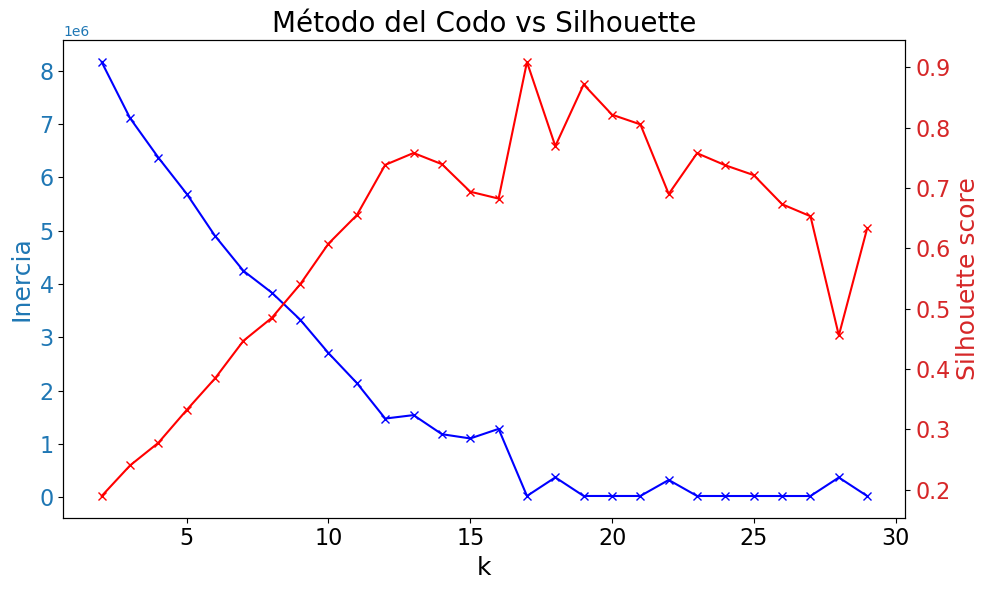

In [34]:
fig, ax1 = plt.subplots(figsize=(10, 6))
 
# --- Eje Y Izquierdo (Inercia) ---
color = 'tab:blue'
ax1.set_xlabel('k', fontsize=18)
ax1.set_ylabel('Inercia', color=color, fontsize=18)
ax1.plot(K, distortions, 'bx-', label='Inercia')
ax1.tick_params(axis='y', labelcolor=color, labelsize=16)
ax1.tick_params(axis='x', labelsize=16)
 
# --- Eje Y Derecho (Silhouette) ---
ax2 = ax1.twinx()  # Instanciamos un segundo eje que comparte el mismo eje x
color = 'tab:red'
ax2.set_ylabel('Silhouette score', color=color, fontsize=18)  
ax2.plot(K, score, 'rx-', label='Silhouette') # Cambié a rojo ('r') para diferenciar
ax2.tick_params(axis='y', labelcolor=color, labelsize=16)
 
plt.title('Método del Codo vs Silhouette', fontsize=20)
fig.tight_layout()  # Para que no se corten las etiquetas
plt.show()
 

#### Se realiza el agrupamiento (clustering) mediante el uso del método [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html). Para determinar el mejor valor de $epsilon$ se calculará la $k$-distancia de cada punto, siendo $k$ = minPts, y se mostrarán gráficamente las $k$-distancias ordenadas de menor a mayor. Para poder determinar la $k$-distancia se recomienda el uso de la función [NearestNeighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html) y para ordenarlas la función [sort](https://numpy.org/doc/stable/reference/generated/numpy.sort.html):

Text(0, 0.5, 'Distancia al k-vecino más cercano')

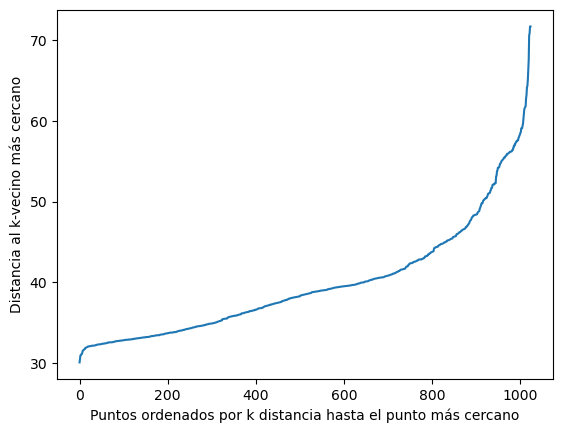

In [35]:
n, dim = X.shape
MinPts = 2*dim

neighbors = NearestNeighbors(n_neighbors=MinPts)
neighbors.fit(X)
distances, indices = neighbors.kneighbors(X)
distances = np.sort(distances[:, MinPts-1])

plt.plot(distances)
plt.xlabel("Puntos ordenados por k distancia hasta el punto más cercano")
plt.ylabel("Distancia al k-vecino más cercano")

#### Se entrena el modelo con DBSCAN para el mejor valor estimado de minPts y $epsilon$. Se muestran el número de grupos (clústeres) creados y el número de datos clasificados como ruido:

In [ ]:
clustering = DBSCAN(eps = 0.6, min_samples= MinPts).fit(X)
n_c = np.max(clustering.labels_)+1
print("grupos detectados: ",n_c)
print("datos clasificados como ruido: ", sum(clustering.labels_ == -1))

plt.title("Agrupamiento obtenido")
scatter = plt.scatter(X[:, 0], X[:,1], c = clustering.labels_, cmap="viridis")
plt.legend(*scatter.legend_elements(), title="Grupos")

Grupos detectados:  16
Datos clasificados como ruido:  0


#### En este caso no podemos visualizar los resultados directamente ya que el espacio de los datos tiene 32 dimensiones. Por ello, transformaremos los datos empleando el método [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html), que hemos estudiado en el tema de reducción de la dimensión, y seleccionaremos solo los 2 primeros componentes del espacio transformado. Con esos 2 componentes, mostremos gráficamente el agrupamiento realizado por el DBSCAN:

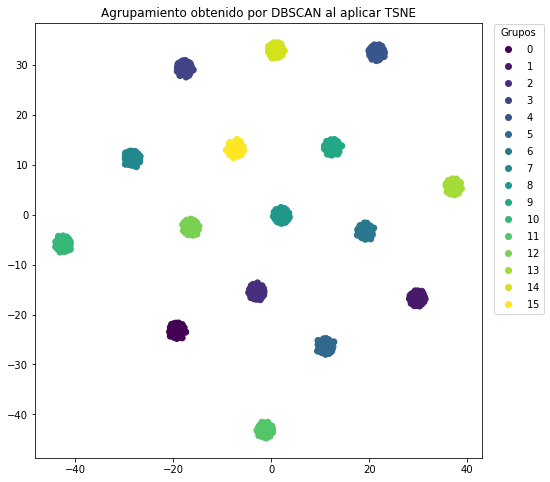